# Black–Scholes PDE Solver using PETSc

This notebook demonstrates how to solve the Black–Scholes PDE for a European call option using an implicit finite-difference method, specifically backward Euler, and PETSc linear solvers.

We compare the numerical solution with the exact Black–Scholes formula and visualize the results.

## Problem Background

We solve the Black–Scholes PDE for a European call option:

$$
\frac{\partial V}{\partial t}
+ \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
+ rS\frac{\partial V}{\partial S}
- rV = 0.
$$

At maturity, the payoff is

$$
V(S,T)=\max(S-K,0).
$$

To solve forward in time, we use the transformed variable

$$
\tau = T-t.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tutorial_module import run_simulation, exact_black_scholes_call

## Numerical Setup

The stock-price domain is

$$
0 \leq S \leq S_{\max}.
$$

We divide the interval into $N$ spatial intervals and use $M$ time steps.

In [2]:
S_max = 400.0
K = 100.0
T = 1.0
r = 0.05
sigma = 0.2
N = 400
M = 400

dS = S_max / N
dt = T / M

S_grid = np.linspace(0.0, S_max, N + 1)

print("dS =", dS)
print("dt =", dt)
print("Number of stock-price grid points =", len(S_grid))

dS = 1.0
dt = 0.0025
Number of stock-price grid points = 401


## Finite Difference Linear System

After applying central finite differences in the stock-price direction and backward Euler in time, each time step requires solving a sparse linear system:

$$
A V^{n+1} = b.
$$

Here, $A$ comes from the finite difference approximation of the Black–Scholes operator, and $b$ contains the option values from the previous time step, adjusted for boundary conditions.

Since the matrix is sparse and structured, we solve this system using PETSc.

In [3]:
# The actual matrix assembly is done inside run_simulation().
# Conceptually, each interior row of A contains the coefficients for
# V_{i-1}^{n+1}, V_i^{n+1}, and V_{i+1}^{n+1}.

print("At each time step, PETSc solves a sparse system of size", N + 1, "x", N + 1)

At each time step, PETSc solves a sparse system of size 401 x 401


## PETSc Solver Workflow

The PETSc part of the solver follows this workflow:

1. Assemble the sparse matrix $A$
2. Create PETSc vectors for the right-hand side and solution
3. Create a KSP solver
4. Attach the matrix to the solver
5. Use LU factorization through the PETSc preconditioner
6. Solve the system at each time step
7. Check the convergence reason after each solve

```python
A = PETSc.Mat().createAIJ([N + 1, N + 1], nnz=3)
bvec = PETSc.Vec().createSeq(N + 1)
xvec = PETSc.Vec().createSeq(N + 1)

ksp = PETSc.KSP().create()
ksp.setOperators(A)
ksp.setType("preonly")
ksp.getPC().setType("lu")
ksp.setFromOptions()

ksp.solve(bvec, xvec)
reason = ksp.getConvergedReason()
```

## Running the Solver

Now we run the full Black–Scholes solver from `tutorial_module.py`.

In [4]:
S, V, price, exact, error, K, T, r, sigma = run_simulation(
    S_max=S_max,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    N=N,
    M=M
)

print("Numerical option price at S = K:", price)
print("Exact Black-Scholes price:", exact)
print("Absolute error:", error)

print("\nModel parameters:")
print("K =", K)
print("T =", T)
print("r =", r)
print("sigma =", sigma)

Numerical option price at S = K: 10.44548743501223
Exact Black-Scholes price: 10.450583572185565
Absolute error: 0.005096137173334014

Model parameters:
K = 100.0
T = 1.0
r = 0.05
sigma = 0.2


## Numerical Solution

The plot below shows the computed European call option value as a function of the stock price.

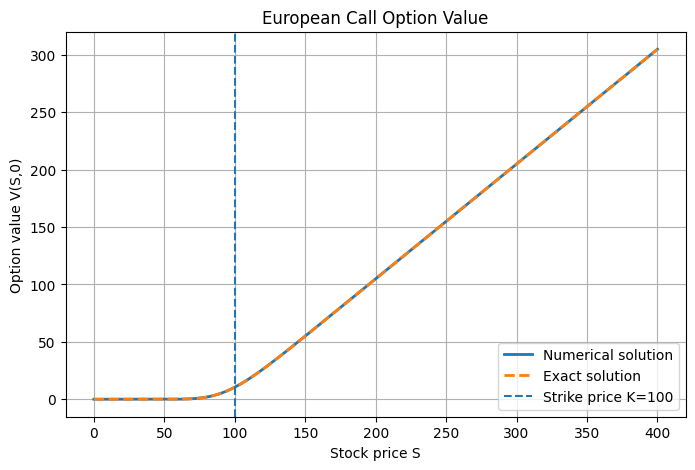

In [5]:
plt.figure(figsize=(8,5))
exact_values = np.array([exact_black_scholes_call(s, K, T, r, sigma) for s in S])

plt.plot(S, V, linewidth=2, label="Numerical solution")
plt.plot(S, exact_values, '--', linewidth=2, label="Exact solution")
plt.axvline(100, linestyle="--", label="Strike price K=100")
plt.xlabel("Stock price S")
plt.ylabel("Option value V(S,0)")
plt.title("European Call Option Value")
plt.legend()
plt.grid(True)
plt.show()

## Accuracy Check

Since the exact Black–Scholes formula is known for a European call option, we compare the numerical price at $S=K$ with the exact value using relative error.

In [6]:
relative_error = error / abs(exact)

print(f"Relative error: {relative_error:.6e}")

Relative error: 4.876414e-04


The relative error is about $.000488$, meaning the numerical price differs from the exact Black–Scholes price by less than one tenth of a percent. This suggests that the backward Euler finite-difference method and PETSc linear solve are producing an accurate approximation for the European call option price at $S=K$.

## Conclusion

This notebook shows the main steps of the numerical method. The Black–Scholes PDE is converted into a sequence of sparse linear systems using finite differences and backward Euler time stepping. PETSc's KSP solver is then used to solve those systems, with LU factorization selected through the preconditioner.

The numerical price is close to the exact Black–Scholes formula, which verifies that the finite-difference/PETSc solver is working as expected.